In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.ticker as mticker 
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "skyblue",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

In [2]:
df = pd.read_parquet("../data/raw/mercedes_benz_final.parquet")
df.head()

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo
0,A-Class,2020,Global,Yellow,Diesel,41265,252,1,Yes
1,A-Class,2020,Global,Black,Petrol,51023,249,1,No
2,A-Class,2020,Global,Grey,Petrol,72819,341,1,Yes
3,A-Class,2020,Global,Black,Petrol,62480,385,1,Yes
4,A-Class,2020,Global,White,Petrol,35189,337,1,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12132666 entries, 0 to 12132665
Data columns (total 9 columns):
 #   Column            Dtype   
---  ------            -----   
 0   Model             category
 1   Year              int64   
 2   Region            category
 3   Color             category
 4   Fuel Type         category
 5   Base Price (USD)  int64   
 6   Horsepower        int64   
 7   Sales Volume      int64   
 8   Turbo             category
dtypes: category(5), int64(4)
memory usage: 428.1 MB


In [4]:
df.shape[1]

9

In [5]:
df.dtypes

Model               category
Year                   int64
Region              category
Color               category
Fuel Type           category
Base Price (USD)       int64
Horsepower             int64
Sales Volume           int64
Turbo               category
dtype: object

In [6]:
df.isnull().sum()

Model               0
Year                0
Region              0
Color               0
Fuel Type           0
Base Price (USD)    0
Horsepower          0
Sales Volume        0
Turbo               0
dtype: int64

In [7]:

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Model,12132666,17,GLC,2091045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,12132666.0,NaN,NaN,NaN,2022.547598,1.658896,2020.0,2021.0,2023.0,2024.0,2025.0
Region,12132666,1,Global,12132666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Color,12132666,10,Black,3031663,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Type,12132666,4,Petrol,5821366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Base Price (USD),12132666.0,NaN,NaN,NaN,104216.921812,67833.882158,35000.0,63462.0,83572.0,119920.0,411246.0
Horsepower,12132666.0,NaN,NaN,NaN,367.45936,119.544615,150.0,275.0,358.0,444.0,831.0
Sales Volume,12132666.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Turbo,12132666,2,Yes,10371297,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
cat_cols = ["Model", "Year", "Region", "Color", "Fuel Type", "Turbo"]
for col in cat_cols:
    vals = df[col].value_counts()
    print(f"\n[{col}] {df[col].nunique()}개")
    print(vals.head(10).to_string())


[Model] 17개
Model
GLC        2091045
A-Class    1618309
GLE        1546092
C-Class    1504928
E-Class    1219554
GLA        1129266
GLB         883773
CLA         564731
GLS         493201
S-Class     374553

[Year] 6개
Year
2023    2301289
2024    2111247
2021    2039570
2022    2000390
2025    1903990
2020    1776180

[Region] 1개
Region
Global    12132666

[Color] 10개
Color
Black     3031663
White     2670085
Silver    1819439
Grey      1819129
Blue       970358
Red        729300
Green      364207
Yellow     363924
Brown      242982
Orange     121579

[Fuel Type] 4개
Fuel Type
Petrol      5821366
Diesel      2571699
Hybrid      2374855
Electric    1364746

[Turbo] 2개
Turbo
Yes    10371297
No      1761369


In [9]:
df["Is_EQ"] = df["Model"].str.contains(r"\bEQ", case=False, na=False)

In [10]:
df["Is_EV"]          = df["Fuel Type"] == "Electric"
df["Is_Electrified"] = df["Fuel Type"].isin(["Electric", "Hybrid"])

In [11]:
df["Is_EQ"] = df["Fuel Type"] == "Electric"

### 세그먼트 분류

In [12]:
def classify_segment(row):
    model = str(row["Model"])
    fuel  = str(row["Fuel Type"])
    
    if "AMG" in model:             return "AMG/Performance"
    if fuel == "Electric":         return "EQ 시리즈(EV)" 
    if model in ["S-Class", "G-Class", "GLS"]: return "럭셔리"
    if model in ["GLC", "GLE", "GLA"]:         return "SUV 중형"
    return "세단 중소형"

df["Segment"] = df.apply(classify_segment, axis=1)

In [13]:
bins   = [0, 50_000, 80_000, 120_000, float("inf")]
labels = ["Entry(<50K)", "Mid(50-80K)", "Premium(80-120K)", "Ultra(120K+)"]
df["Price_Band"] = pd.cut(df["Base Price (USD)"], bins=bins, labels=labels)
display(df[["Model","Is_EQ","Is_EV","Is_Electrified","Segment","Price_Band"]].head(10))

,Model,Is_EQ,Is_EV,Is_Electrified,Segment,Price_Band
0,A-Class,False,False,False,세단 중소형,Entry(<50K)
1,A-Class,False,False,False,세단 중소형,Mid(50-80K)
2,A-Class,False,False,False,세단 중소형,Mid(50-80K)
3,A-Class,False,False,False,세단 중소형,Mid(50-80K)
4,A-Class,False,False,False,세단 중소형,Entry(<50K)
5,A-Class,False,False,False,세단 중소형,Mid(50-80K)
6,A-Class,False,False,False,세단 중소형,Mid(50-80K)
7,A-Class,False,False,False,세단 중소형,Mid(50-80K)
8,A-Class,False,False,False,세단 중소형,Mid(50-80K)
9,A-Class,False,False,False,세단 중소형,Entry(<50K)


#### 연도별 판매량 분포 확인

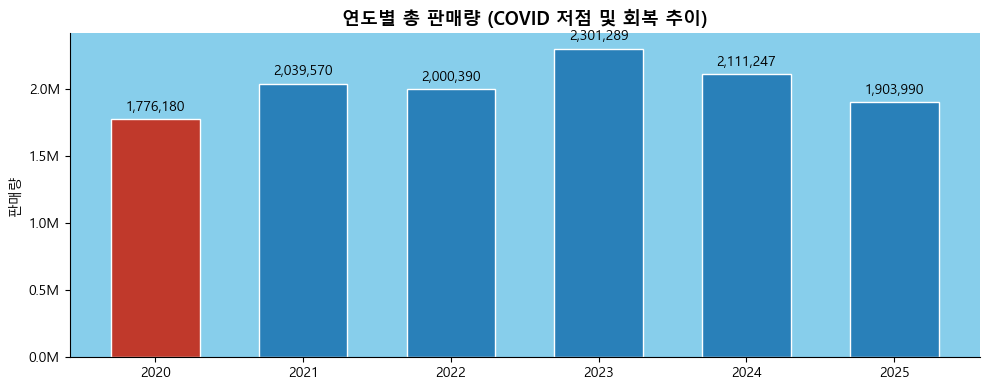

In [14]:
yr_vol = df.groupby("Year")["Sales Volume"].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(yr_vol["Year"], yr_vol["Sales Volume"],
              color=["#c0392b" if y == 2020 else "#2980b9" for y in yr_vol["Year"]],
              width=0.6, edgecolor="white")
ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=10)
ax.set_title("연도별 총 판매량 (COVID 저점 및 회복 추이)")
ax.set_ylabel("판매량")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("../outputs/figures/00_yearly_volume.png", dpi=150, bbox_inches="tight")
plt.show()

#### 모델별 판매 상위 5순위

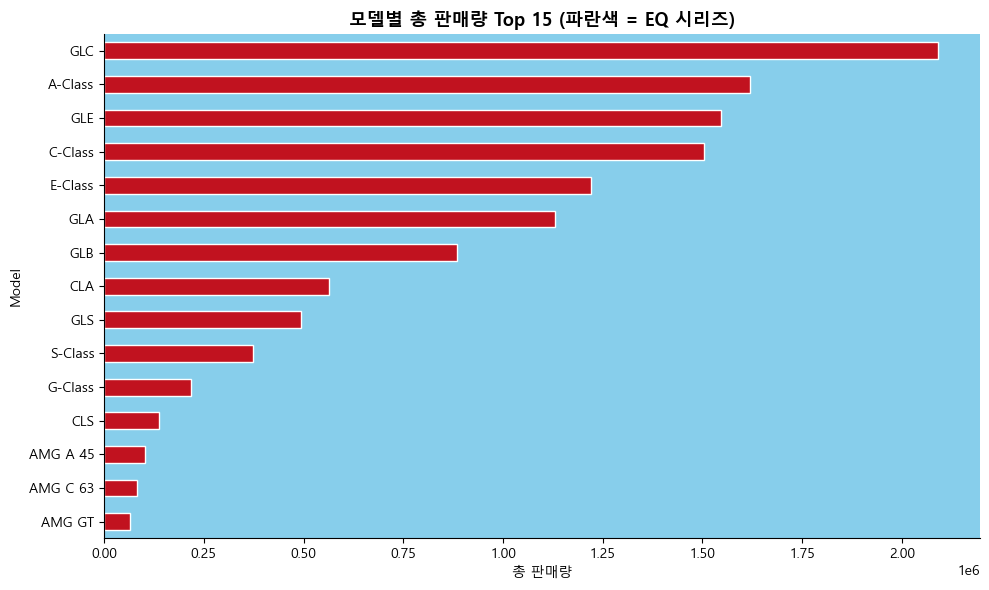

In [15]:
model_vol = df.groupby("Model")["Sales Volume"].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#003049" if m.startswith("EQ") else "#c1121f" for m in model_vol.index]
model_vol.plot(kind="barh", ax=ax, color=colors[::-1], edgecolor="white")
ax.set_title("모델별 총 판매량 Top 15 (파란색 = EQ 시리즈)")
ax.set_xlabel("총 판매량")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/figures/00_top15_models.png", dpi=150, bbox_inches="tight")
plt.show()

#### 데이터 저장

In [16]:
df.to_parquet("../data/processed/mercedes_processed.parquet", index=False)
print(f"전체 데이터 : {len(df):,}행")

전체 데이터 : 12,132,666행


In [17]:
eq_df = df[df["Fuel Type"] == "Electric"].copy()
print(f"전기차(EV) 데이터 : {len(eq_df):,}행")

eq_df.to_parquet("../data/processed/eq_series.parquet", index=False)

전기차(EV) 데이터 : 1,364,746행
